In [20]:
# 📌 Step 1: Import libraries
import os
import numpy as np
from skimage.io import imread, imsave
from matplotlib import pyplot as plt

from csbdeep.utils import normalize
from n2v.models import N2V, N2VConfig
import tensorflow as tf
print("Eager mode enabled?", tf.executing_eagerly())

gpus = tf.config.list_physical_devices('GPU')
print("Available GPUs:", gpus)


Eager mode enabled? True
Available GPUs: []


In [21]:
import os
import numpy as np
from skimage.io import imread
from skimage.transform import resize


image_dir = r'Z:\Workspace\Jay\n2v_project\images'
image_list = sorted([f for f in os.listdir(image_dir) if f.endswith(('.png', '.jpg', '.tif'))])
imgs = []

target_shape = (256, 256)  # 預設輸出大小，需能被 4 整除

for fname in image_list:
    img_path = os.path.join(image_dir, fname)
    img = imread(img_path)

    # 處理灰階圖
    if img.ndim == 2:
        img = img[..., np.newaxis]

    # 處理格式錯誤的彩色圖，例如 (C, H, W) 或 (H, C, W)
    elif img.ndim == 3:
        if img.shape[0] in [1, 3] and img.shape[0] != max(img.shape):  # (C, H, W)
            print(f"🔄 Transposing (C, H, W) → (H, W, C): {fname}")
            img = np.transpose(img, (1, 2, 0))
        elif img.shape[1] in [1, 3] and img.shape[1] != max(img.shape):  # (H, C, W)
            print(f"🔄 Transposing (H, C, W) → (H, W, C): {fname}")
            img = np.transpose(img, (0, 2, 1))

    # Resize 成固定大小（H, W）並保留 channel 數
    resized = resize(img, (*target_shape, img.shape[-1]), preserve_range=True, anti_aliasing=True)
    resized = resized.astype(np.float32)  # 統一格式，防止預測錯誤

    imgs.append(resized)

X = np.array(imgs)
Y = X.copy()

print(f"✅ Loaded {X.shape[0]} images. Final shape: {X.shape}")


✅ Loaded 111 images. Final shape: (111, 256, 256, 3)


In [22]:
# ✅ Normalize images
X = normalize(X, 1, 99.8, axis=(1, 2, 3))

In [ ]:
# 🛠️ Step 3: Configure model
config = N2VConfig(
    X,
    unet_kern_size=3,
    train_steps_per_epoch=50,
    train_epochs=10,
    train_loss='mse',
    batch_norm=True,
    train_batch_size=4,
    n2v_perc_pix=0.198,
    n2v_patch_shape=(64, 64),
    n2v_neighborhood_radius=5
)


In [24]:
print(X.shape)
print(Y.shape)

(111, 256, 256, 3)
(111, 256, 256, 3)


In [25]:
# ...existing code...
import os
import shutil
import time
from n2v.models import N2V

# ✅ 用全新目錄名稱，避開已污染的舊資料夾
model_name = 'N2VModel_v6'
model_path = os.path.join('models', model_name)

# 若存在同名資料夾或檔案，直接移除
if os.path.isfile(model_path):
    os.remove(model_path)
elif os.path.isdir(model_path):
    shutil.rmtree(model_path)
time.sleep(1)

# 確保 models 資料夾存在
os.makedirs('models', exist_ok=True)
# 建立乾淨資料夾
os.makedirs(model_path, exist_ok=True)
print(f"✅ 已建立 {model_path}")

# 建立模型並訓練
model = N2V(config=config, name=model_name, basedir='models/')
model.train(X, Y)
# ...existing code...

✅ 已建立 models\N2VModel_v6


n2v/models/n2v_standard.py:447: UserWarning: output path for model already exists, files may be overwritten: models/N2VModel_v6
  warnings.warn(


8 blind-spots will be generated per training patch of size (64, 64).


Preparing validation data: 100%|██████████| 111/111 [00:00<00:00, 217.94it/s]

Epoch 1/100


4/4 [==============================] - 15s 3s/step - loss: 0.9805 - n2v_mse: 0.9805 - n2v_abs: 0.7504 - val_loss: 116460.3672 - val_n2v_mse: 110031.0156 - val_n2v_abs: 251.0300 - lr: 4.0000e-04
Epoch 2/100
4/4 [==============================] - 9s 3s/step - loss: 0.5644 - n2v_mse: 0.5644 - n2v_abs: 0.5281 - val_loss: 107945.6406 - val_n2v_mse: 102015.4062 - val_n2v_abs: 240.8997 - lr: 4.0000e-04
Epoch 3/100
4/4 [==============================] - 9s 3s/step - loss: 0.5904 - n2v_mse: 0.5904 - n2v_abs: 0.5544 - val_loss: 101063.5859 - val_n2v_mse: 95535.5938 - val_n2v_abs: 232.3672 - lr: 4.0000e-04
Epoch 4/100
4/4 [==============================] - 9s 3s/step - loss: 0.5389 - n2v_mse: 0.5389 - n2v_abs: 0.5238 - val_loss: 97354.4766 - val_n2v_mse: 92040.9375 - val_n2v_abs: 227.5282 - lr: 4.0000e-04
Epoch 5/100
4/4 [==============================] - 9s 3s/step - loss: 0.6027 - n2v_mse: 0.6027 - n2v_abs: 0.5377 - val_loss: 95590.3125 - val_n2v_mse: 90372.1797 - val_n2v_abs: 225.1494 - lr: 4.

In [26]:
# 🔮 Step 5: Predict on the first image
denoised = model.predict(X[0][np.newaxis, ...], axes='SYXC')


1/1 [==============================] - 0s 417ms/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.025316456..1.050633].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.18515646..1.1285454].


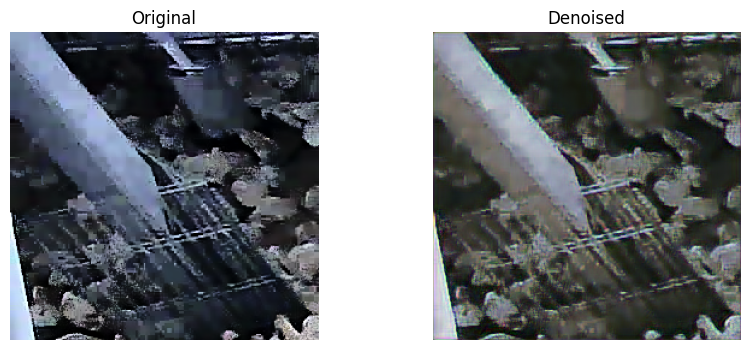

In [27]:
# 🎨 Step 6: Show comparison
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(X[0].squeeze())
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Denoised")
plt.imshow(denoised[0].squeeze())
plt.axis('off')
plt.show()

In [28]:
# 💾 Step 7: Predict and save all RGB images
import os
from skimage.io import imsave

os.makedirs('output_3', exist_ok=True)
for idx, img in enumerate(X):
    # 預測
    denoised = model.predict(img[np.newaxis, ...], axes='SYXC')  # shape: (1, H, W, C)

    # 不使用 squeeze，以免壓掉 RGB 的 channel
    denoised_img = denoised[0]  # shape: (H, W, 3)

    # 正規化回 0~255 並轉為 uint8
    img_to_save = (denoised_img * 255).astype(np.uint8)

    # 檔名與輸出
    orig_filename = image_list[idx]
    output_path = os.path.join('output_3', f'denoised_{orig_filename}')
    imsave(output_path, img_to_save)

    print(f"💾 Saved to {output_path}")


1/1 [==============================] - 0s 102ms/step
💾 Saved to output_3\denoised_20250501_1836_0001_0000.png
1/1 [==============================] - 0s 110ms/step
💾 Saved to output_3\denoised_20250501_1836_0001_0001.png
1/1 [==============================] - 0s 102ms/step
💾 Saved to output_3\denoised_20250501_1836_0001_0002.png
1/1 [==============================] - 0s 103ms/step
💾 Saved to output_3\denoised_20250501_1836_0001_0003.png
1/1 [==============================] - 0s 103ms/step
💾 Saved to output_3\denoised_20250501_1836_0001_0004.png
1/1 [==============================] - 0s 101ms/step
💾 Saved to output_3\denoised_20250501_1836_0001_0005.png
1/1 [==============================] - 0s 102ms/step
💾 Saved to output_3\denoised_20250501_1836_0001_0006.png
1/1 [==============================] - 0s 105ms/step
💾 Saved to output_3\denoised_20250501_1836_0001_0007.png
1/1 [==============================] - 0s 106ms/step
💾 Saved to output_3\denoised_20250501_1836_0001_0008.png
1/1 [=====